In [1]:
import sys; sys.path.append("../../"); sys.path.append("../../../.."); sys.path.append("../../../gmsh/"); sys.path.append("../../experiments/"); sys.path.append("../../../")
import experiment_helper
import igl
from periodic_simulation_setup import *
import json



In [2]:
a = 2
avg_len = 0.08
radius = 0.8

In [3]:
use_half_period = False

In [4]:

h = 5
m, marker = pattern_generator_using_gmsh.get_cosine_curve(h, avg_len, avg_len, amplitude=0.1653061224489796, end_threshold = 0.0, use_half_period=use_half_period)

finalMarkers = np.where(np.array(marker) == 1)[0]
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, flip_orientation= 0)
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, axis = 1, flip_orientation= 1)

# vertices = m.vertices()
# vertices *= 4
# m = MeshFEM.mesh.Mesh(vertices, m.elements())
fusedVtx = get_fusedVtx_using_markers(len(m.vertices()), finalMarkers)


num_seg: 62
121


In [5]:

ipu = inflation.InflatablePeriodicUnit(m, fusedVtx = fusedVtx, epsilon = 1e-9)

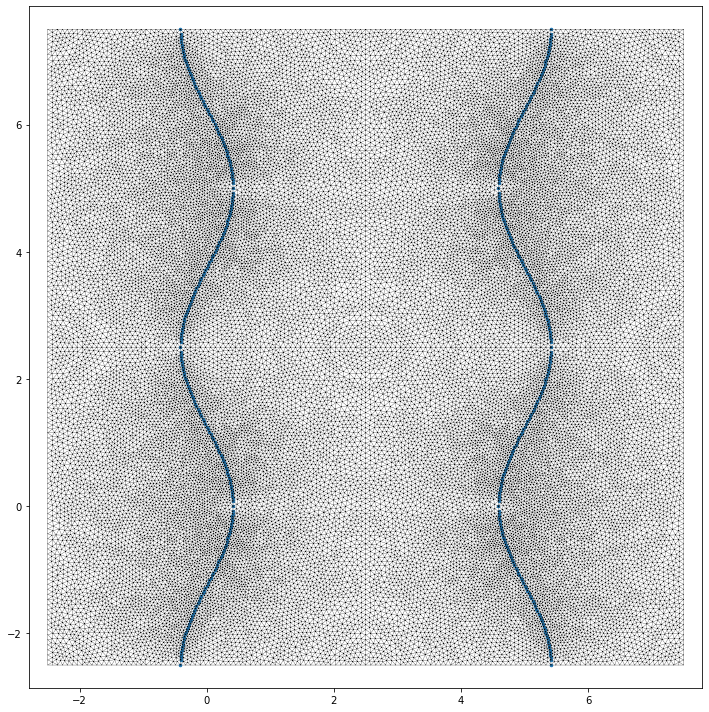

In [6]:
visualization.plot_2d_mesh(m, pointList = fusedVtx, width = 10, height = 10)

In [63]:
num_plots = 100
amps = np.linspace(0, 0.9, num_plots)

In [103]:
def plot_amplitude(i):
    base_cosine_curve, curve_edges, boundary_vxs, boundary_lines = pattern_generator_using_gmsh.get_cosine_curve(h, avg_len, avg_len, amplitude=amps[i], end_threshold = 0.0, use_half_period=use_half_period, return_line_segments=True)

    x = base_cosine_curve[:, [0]]
    y = base_cosine_curve[:, [1]]
    mirror_right_x = 5 - x
    mirror_up_y = 5 - y
    z = base_cosine_curve[:, [2]]

    total_curves = np.concatenate((base_cosine_curve, np.concatenate((x, mirror_up_y, z), axis = 1), np.concatenate((mirror_right_x, y, z), axis = 1), np.concatenate((mirror_right_x, mirror_up_y, z), axis = 1)))

    total_edges = np.concatenate((curve_edges - 1, curve_edges + len(base_cosine_curve) - 1, curve_edges + 2 * len(base_cosine_curve) - 1, curve_edges + 3 * len(base_cosine_curve) - 1))

    visualization.plot_line_segments(total_curves, total_edges, color = 'black')
    low = -2.5
    high = 7.5
    plt.plot([low, low], [low, high], linestyle='--', dashes=(5, 5), c = 'black')
    plt.plot([low, high], [low, low], linestyle='--', dashes=(5, 5), c = 'black')
    plt.plot([low, high], [high, high], linestyle='--', dashes=(5, 5), c = 'black')
    plt.plot([high, high], [low, high], linestyle='--', dashes=(5, 5), c = 'black')
    plt.axis('off')
    plt.savefig('cosine_curves/{:02d}.png'.format(83 - i), dpi = 300, bbox_inches='tight')

num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62


/Users/yren/Develop/Inflatables/python/periodic_patches/SIGGRAPH_figures/patch_collection/../../../visualization.py:481: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(width, height))


num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62
num_seg: 62


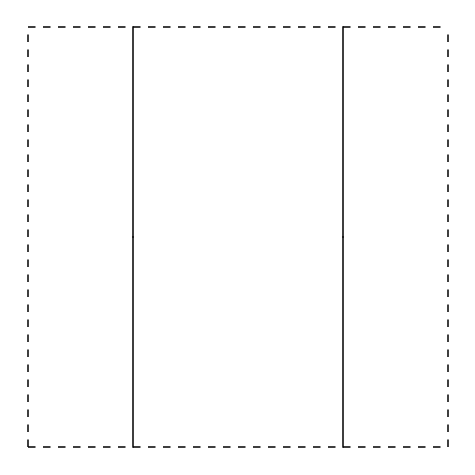

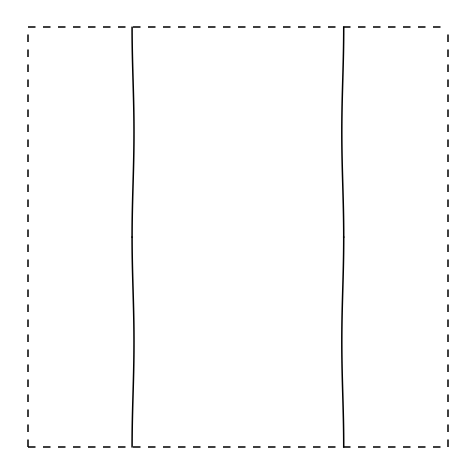

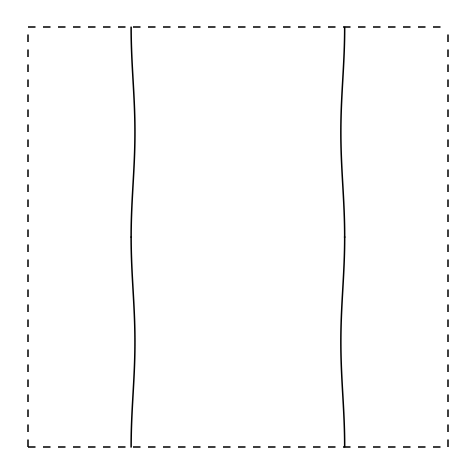

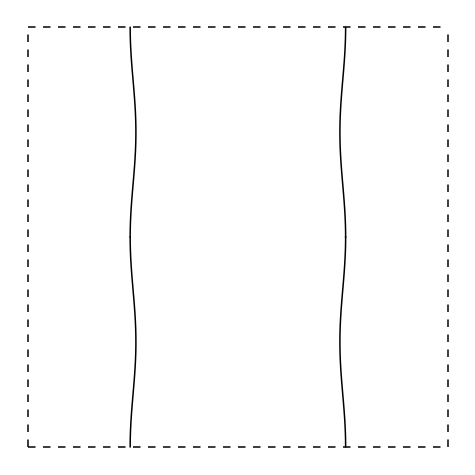

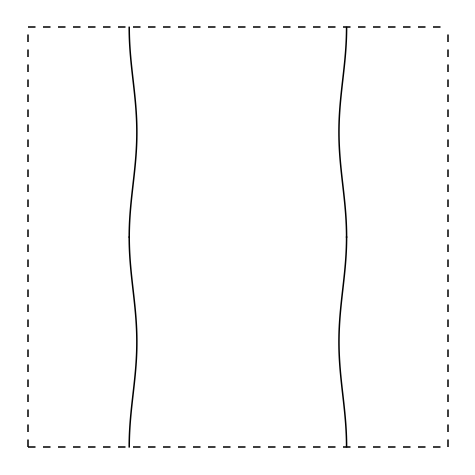

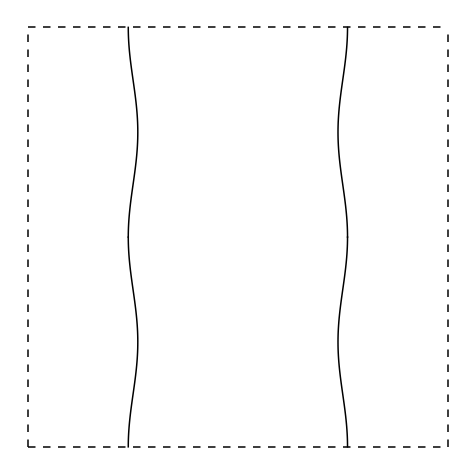

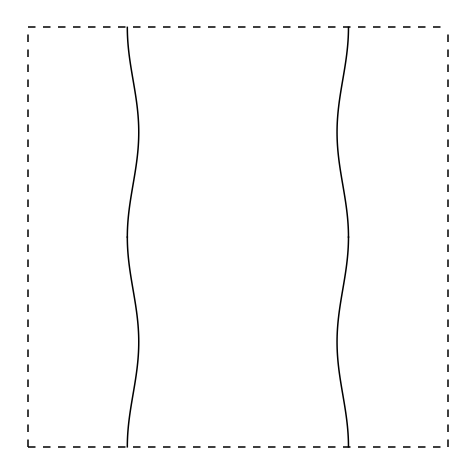

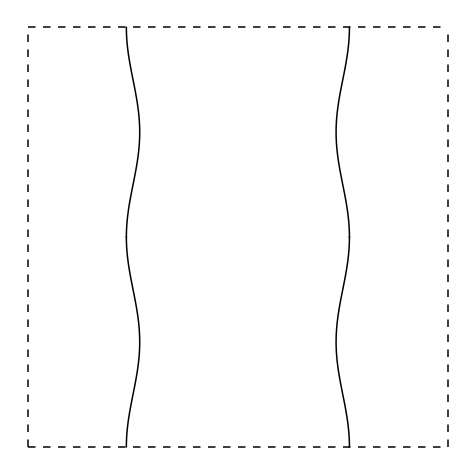

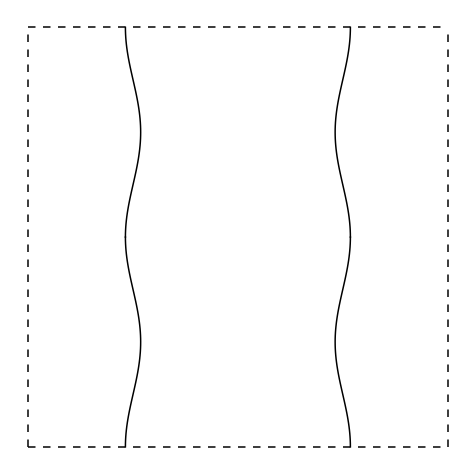

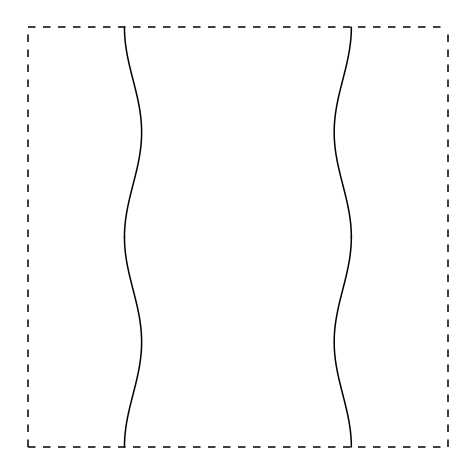

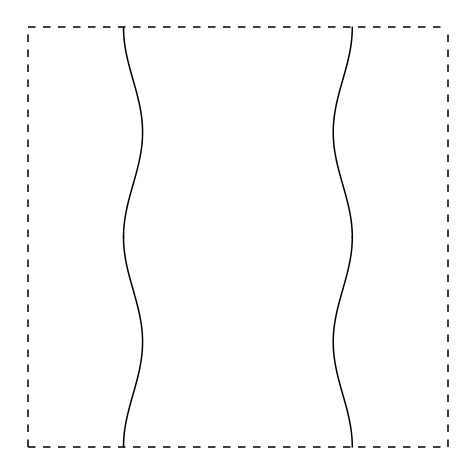

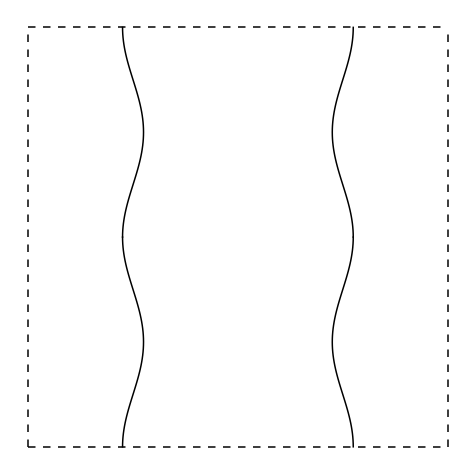

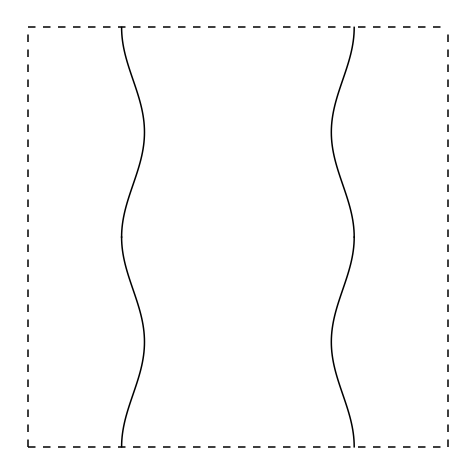

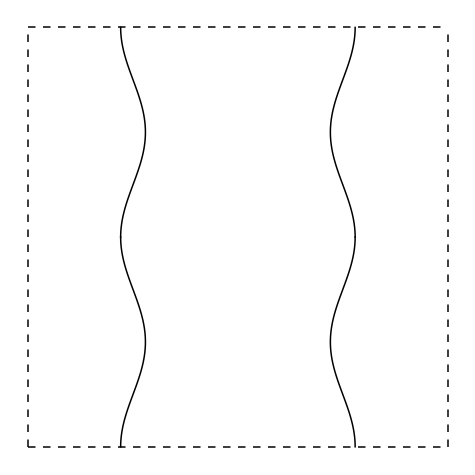

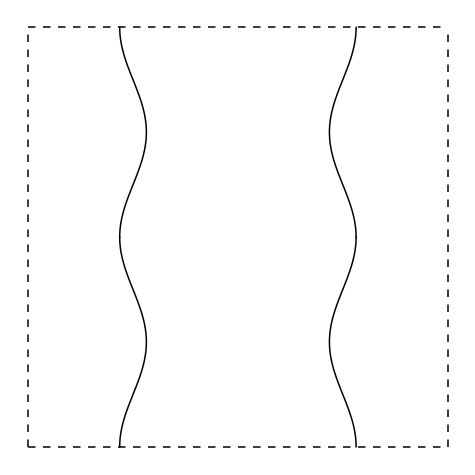

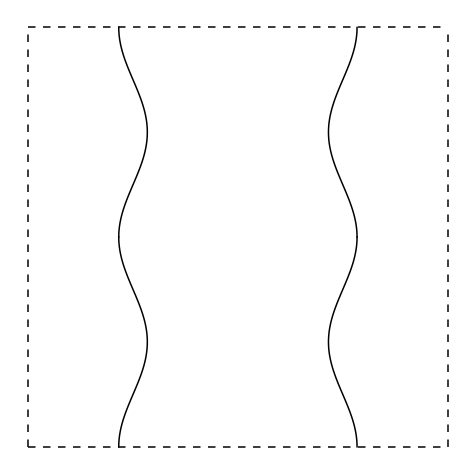

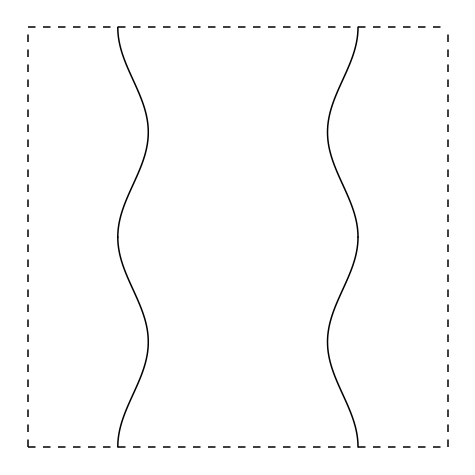

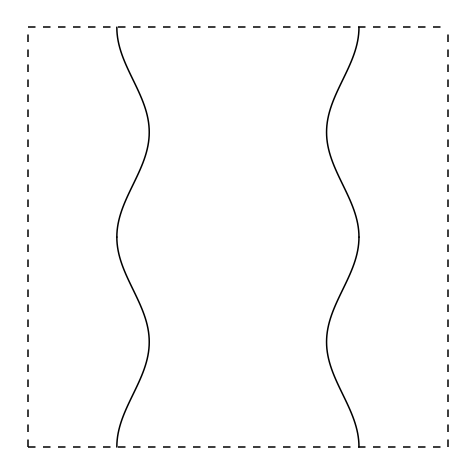

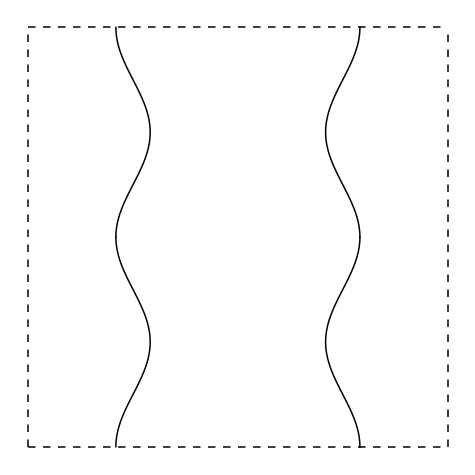

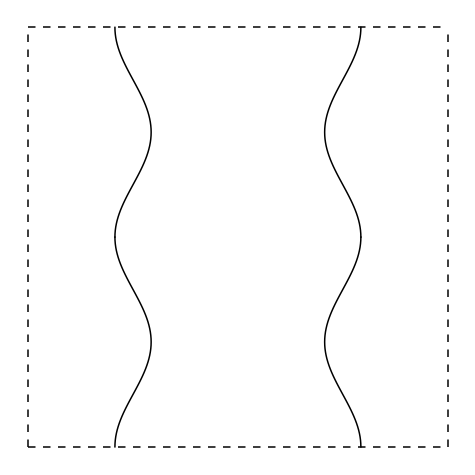

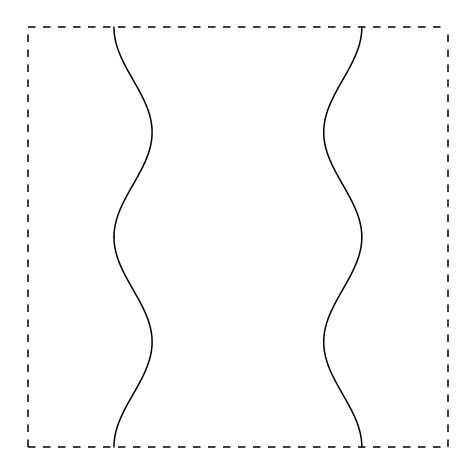

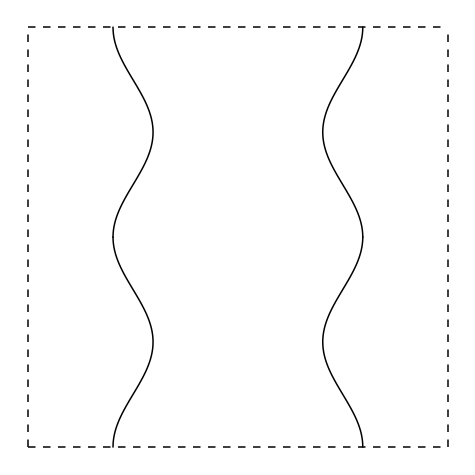

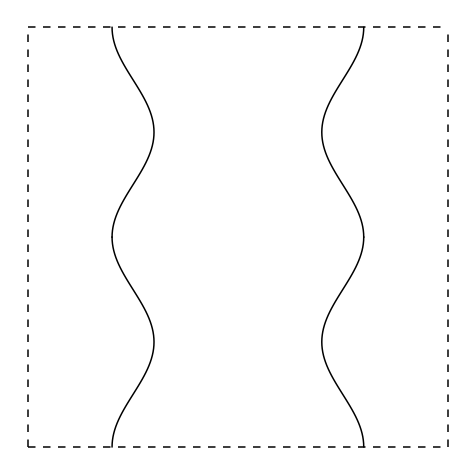

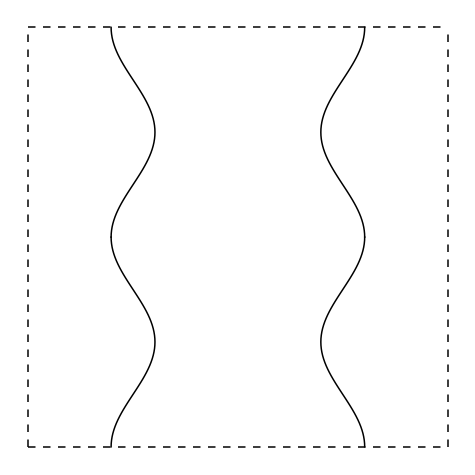

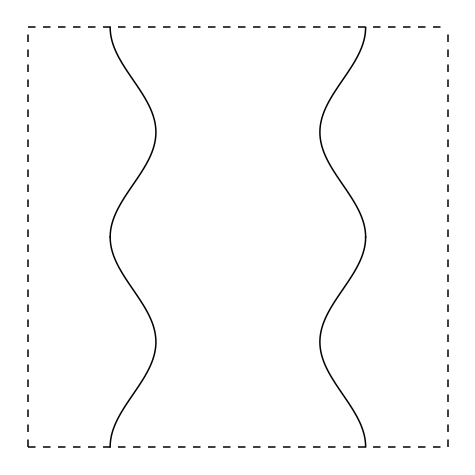

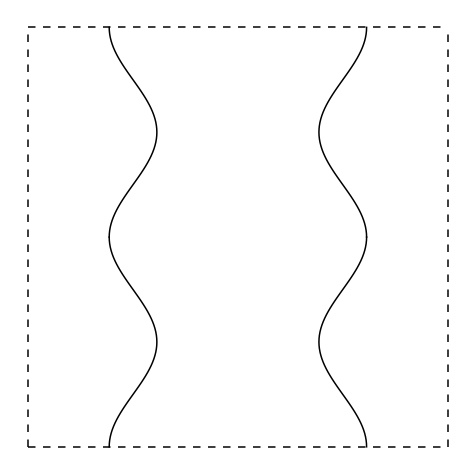

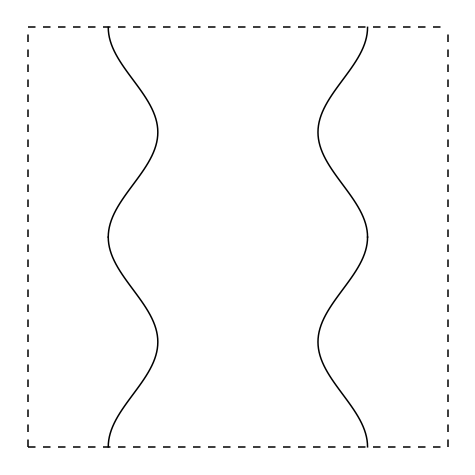

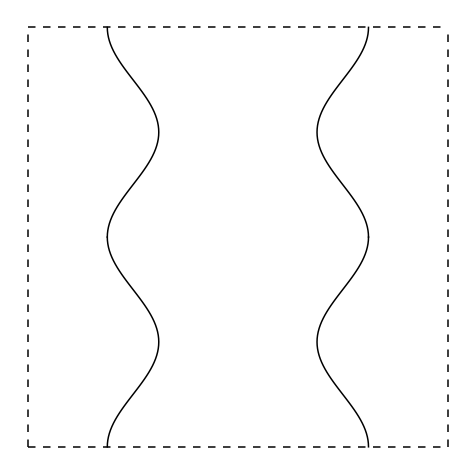

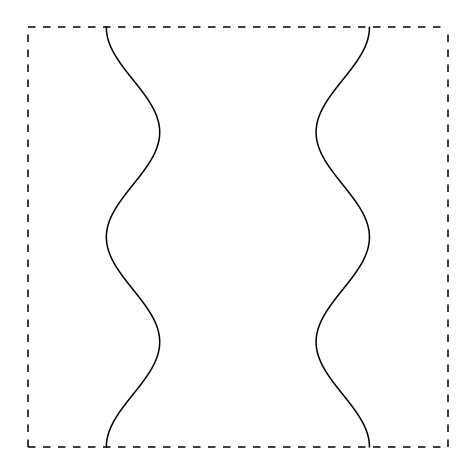

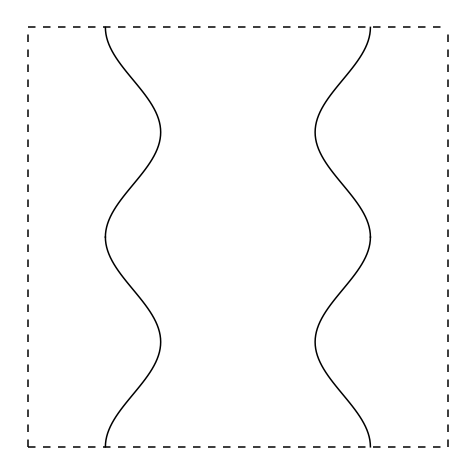

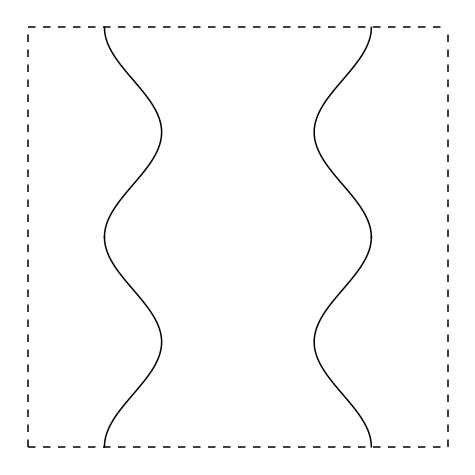

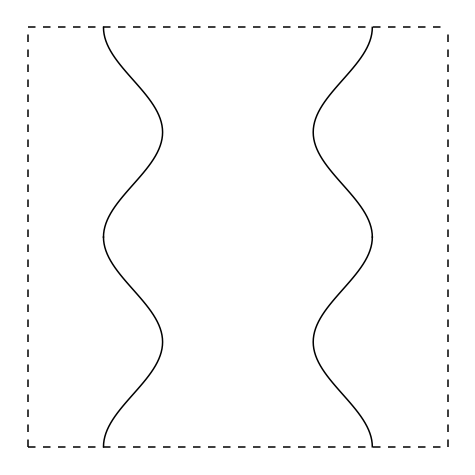

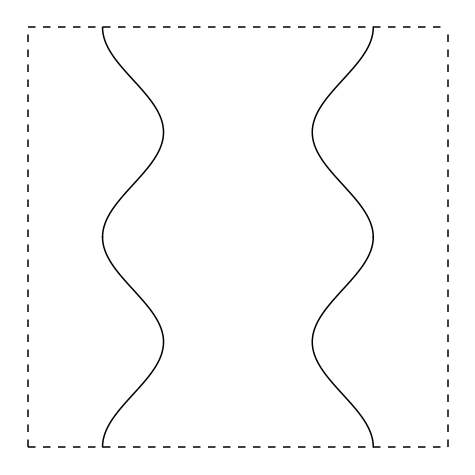

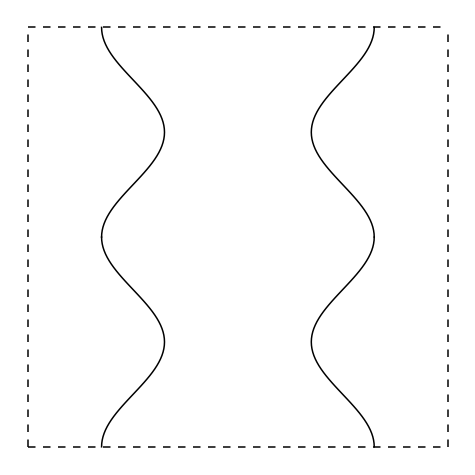

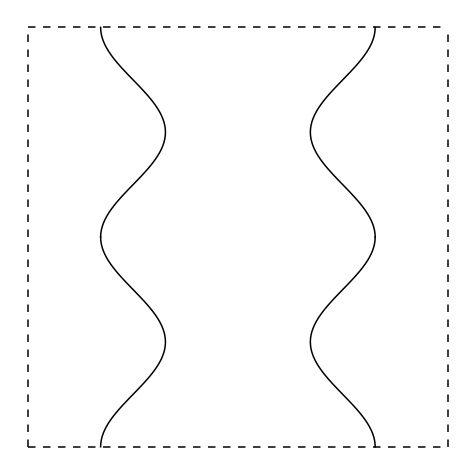

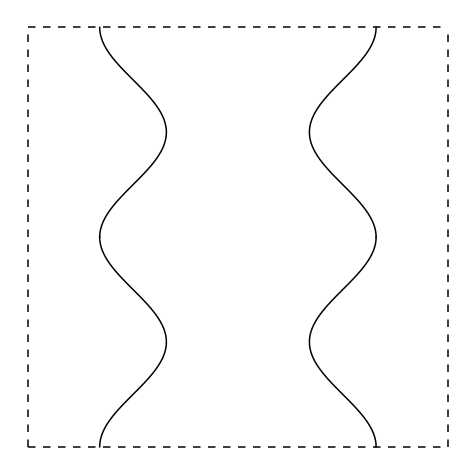

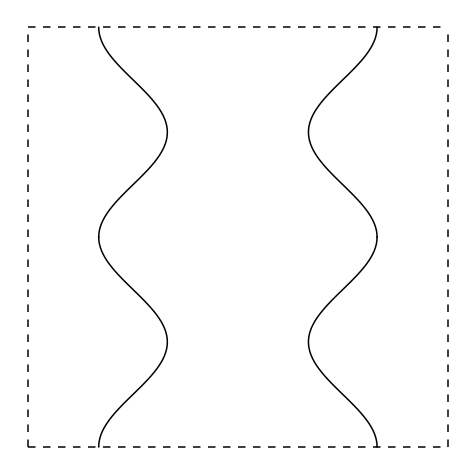

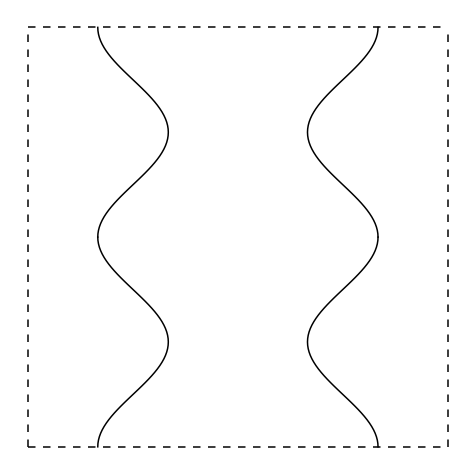

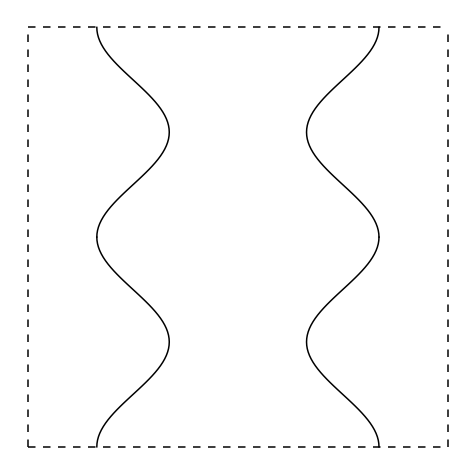

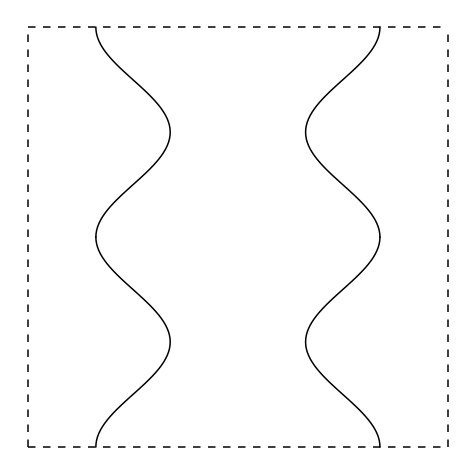

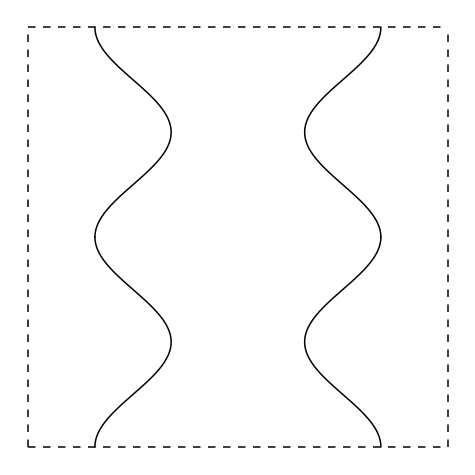

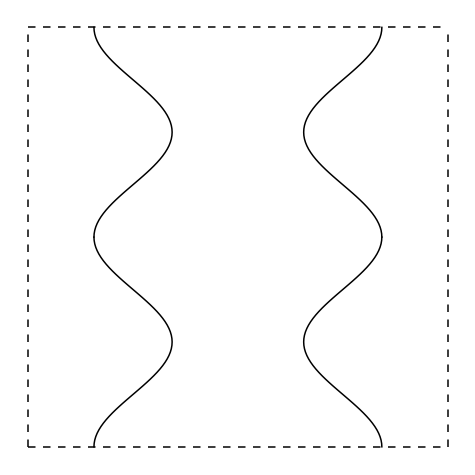

In [104]:
for i in range(42):
    plot_amplitude(i)

In [34]:
x = base_cosine_curve[:, [0]]
y = base_cosine_curve[:, [1]]
mirror_right_x = 5 - x
mirror_up_y = 5 - y
z = base_cosine_curve[:, [2]]

In [35]:
total_curves = np.concatenate((base_cosine_curve, np.concatenate((x, mirror_up_y, z), axis = 1), np.concatenate((mirror_right_x, y, z), axis = 1), np.concatenate((mirror_right_x, mirror_up_y, z), axis = 1)))

In [36]:
total_edges = np.concatenate((curve_edges - 1, curve_edges + len(base_cosine_curve) - 1, curve_edges + 2 * len(base_cosine_curve) - 1, curve_edges + 3 * len(base_cosine_curve) - 1))

In [39]:
importlib.reload(visualization)

<module 'visualization' from '/Users/yren/Develop/Inflatables/python/periodic_patches/SIGGRAPH_figures/patch_collection/../../../visualization.py'>

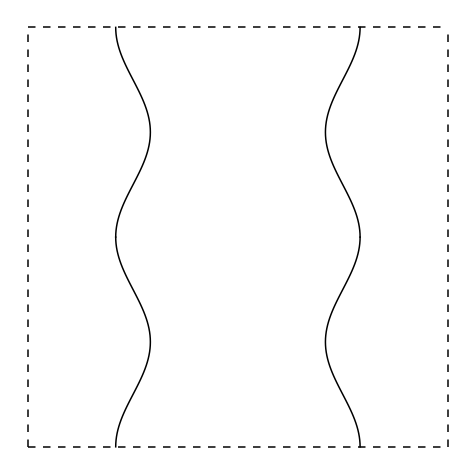

In [62]:
visualization.plot_line_segments(total_curves, total_edges, color = 'black')
low = -2.5
high = 7.5
plt.plot([low, low], [low, high], linestyle='--', dashes=(5, 5), c = 'black')
plt.plot([low, high], [low, low], linestyle='--', dashes=(5, 5), c = 'black')
plt.plot([low, high], [high, high], linestyle='--', dashes=(5, 5), c = 'black')
plt.plot([high, high], [low, high], linestyle='--', dashes=(5, 5), c = 'black')
plt.axis('off')
plt.savefig('cosine_curve.png', dpi = 300, bbox_inches='tight')

viewer = TriMeshViewer(ipu, width=768, height=640)
viewer.showWireframe(False)
viewer.show()

In [20]:
# pressure = 0.8
stiffness_pressure = 0.4
scale_factor_pressure = 0.01

In [21]:
allowBending = False
useTFT = True
disableFusedRegionTFT = False

In [22]:
def cb(i):
    viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])

In [23]:
# Choose strategy for constraining rigid motion
fixedVars, hessianShift = periodic_unit_helper.get_center_fixedVars(ipu), 0
if not allowBending:
    fixedVars, hessianShift = [ipu.numVars() - 2, ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6

ipu.sheet.setUseTensionFieldEnergy(useTFT)
ipu.sheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    ipu.sheet.disableFusedRegionTensionFieldTheory(False)
ipu.sheet.pressure = stiffness_pressure

benchmark.reset()
print(allowBending, stiffness_pressure, hessianShift, fixedVars)

opts.niter = 500
opts.gradTol = 1e-10
print(opts.factorizer)

cr = inflation.inflation_newton(ipu, fixedVars, options = opts, callback=cb, hessianShift = hessianShift)
viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
benchmark.report()

False 0.4 1e-06 [193539, 193540]
CholeskyProvider.CatamariNesdis
InflatablePeriodicUnit.hessianSparsityPattern	0.373697	1
    Compress Matrix	0.166476	2
    InflatablePeriodicUnit.computeAHA	0.101194	1
    InflatablePeriodicUnit.hessianPeriodicPressurePotential	0.00645494	1
            baseHessianSparsityPattern	9.53674e-07	1
InflatableSheet setVars	0.00107312	1
Newton iterations	163.407	1
    InflatableSheet energy	0.00378704	3
    Newton iterate	163.402	195
        Backtracking	1.98183	194
            InflatableSheet energy	0.790055	860
            InflatableSheet setVars	0.390625	288
        Compute descent direction	57.8194	194
            newton_step	57.8188	194
                Catamari Symbolic Factorize	0.514173	1
                    CatamariConverter	0.0394959	1
                    Construct plan	0.0116491	1
                        Build	0.0083878	1
                    SparseLDL.Factor	0.0856202	1
                        supernodal_ldl.Factorization.Factor	0.0856161	1
         

In [24]:
cr.success

True

In [25]:
import os

In [26]:
tag = 'cosine_curve_max_min_bending_stiffness'

In [27]:
output_folder = 'selected_patterns/{}/'.format(tag)
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

In [28]:
import parametrization_helper

In [29]:
parametrization_helper.export_top_bottom_mesh(ipu.sheet, output_folder, tag, 'selected')

m.save("{}/mesh_{}.obj".format(output_folder, tag))
np.save("{}/fusedVtx_{}.npy".format(output_folder, tag), fusedVtx)

In [70]:
import sys

In [73]:
sys.path.append('../../experiments/parametrization_experiments/')

In [74]:
import parametrization_experiment_helper

In [77]:
parametrization_experiment_helper.Pattern_data[1]['stiffness_path']

'/Users/yren/Develop/Inflatables/python/periodic_patches/experiments/parallelized_experiments/output/cosine_curve_amplitude_full_period/2023_12_17_15_52/'

In [101]:
def plot_saved_stiffness(i):
    sampled_stiffness = np.load('/Users/yren/Develop/Inflatables/python/periodic_patches/experiments/parallelized_experiments/output/cosine_curve_amplitude_full_period/2023_12_17_15_52/{}/bending_stiffness_values_cosine_curve_amplitude_full_period_{}.npy'.format(i, i))
    sampled_alpha = np.load('/Users/yren/Develop/Inflatables/python/periodic_patches/experiments/parallelized_experiments/output/cosine_curve_amplitude_full_period/2023_12_17_15_52/{}/sampled_alphas_cosine_curve_amplitude_full_period_{}.npy'.format(i, i))

    r = list(sampled_stiffness) + list(sampled_stiffness)
    theta = np.array(list(sampled_alpha) + list(np.pi + np.array(sampled_alpha))) + np.pi / 2


    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.plot(theta, r, linewidth = 2)
    # ax.set_rticks([0.5, 1, 1.5, 2])  # Less radial ticks
    # ax.set_rlabel_position(-22.5)  # Move radial labels away from plotted line
    ax.grid(True)

    # ax.set_title("Bending stiffness", va='bottom')
    plt.tight_layout()
    plt.savefig('cosine_curves_stiffness/{:02d}.png'.format(41 - i), dpi = 300)
    plt.close()

In [102]:
for i in range(21):
    plot_saved_stiffness(i)